# The k-Nearest Neighbors (k-NN) Algorithm

**The k-Nearest Neighbors (k-NN) algorithm** is a simple, intuitive, and widely used method for both classification and regression tasks in machine learning. 

### Overview of k-Nearest Neighbors (k-NN)

### How k-NN Works

**Data Preparation:** Gather and preprocess your dataset. Ensure features are normalized or scaled if they vary widely in range.

**Choose k:** Decide on the number of nearest neighbors (k) to consider.

**Compute Distance:** Calculate the distance between the query point (the point for which you want to make a prediction) and all points in the training set. Common distance metrics include **Euclidean**, Manhattan, and Minkowski distances.

**Identify Neighbors:** Select the k points in the training set that are closest to the query point based on the computed distance.

**Make a Prediction:** The query point is assigned to the class most common among its k nearest neighbors.


## How to choose the value of k for KNN Algorithm?

The value of k is very crucial in the KNN algorithm to define the number of neighbors in the algorithm. The value of k in the 
k-nearest neighbors (k-NN) algorithm should be chosen based on the input data. 

If the input data has more outliers or noise, a higher value of k would be better. It is recommended to choose an odd value for k to avoid ties in classification. Cross-validation methods can help in selecting the best k value for the given dataset.

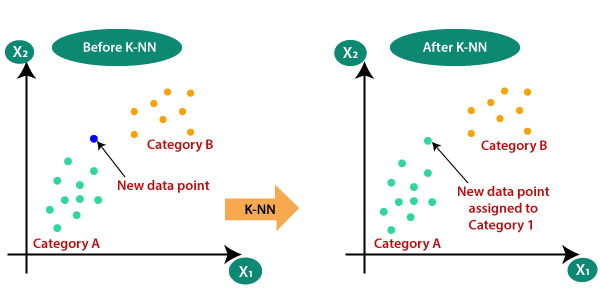

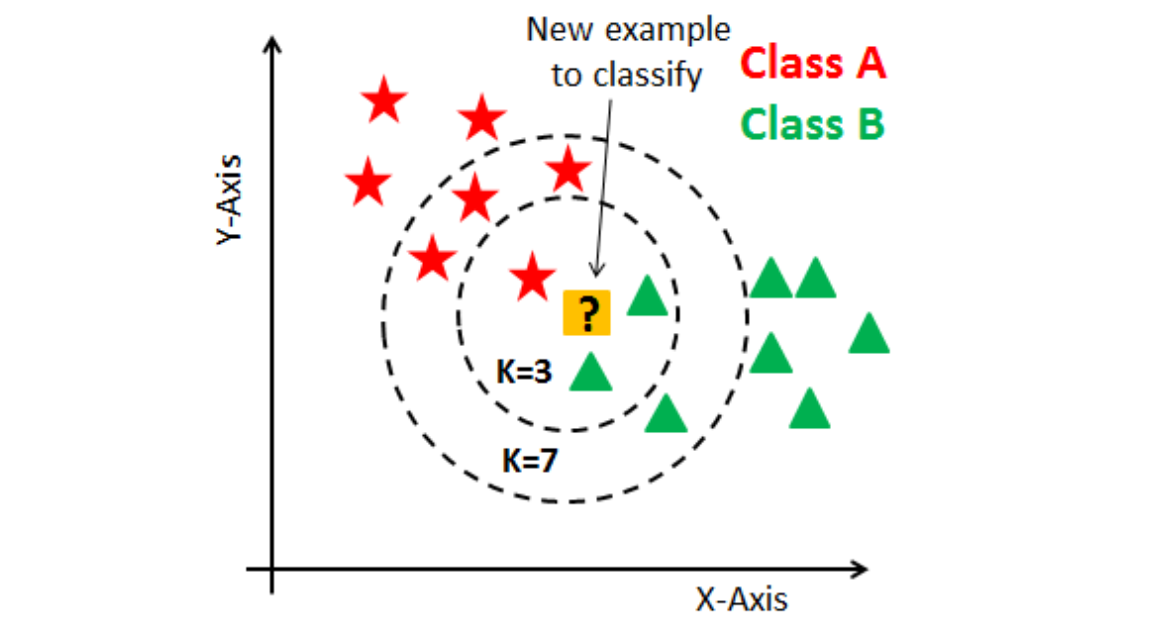

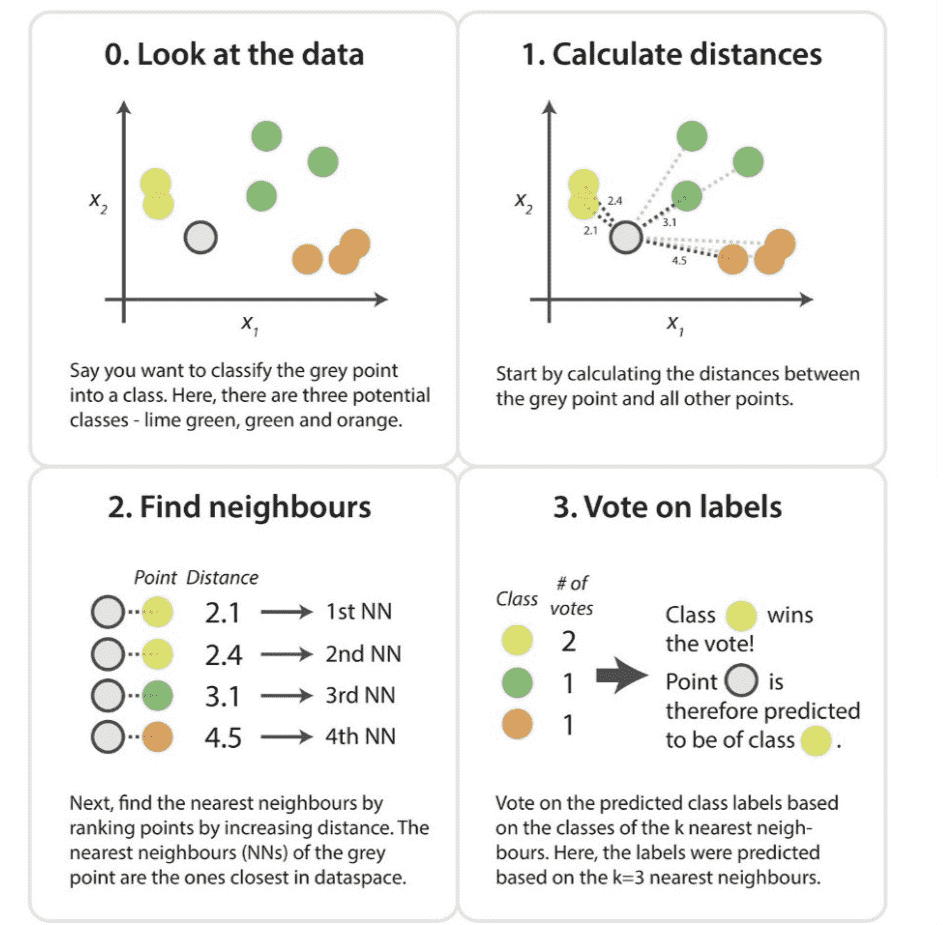

### Euclidean Distance Equation

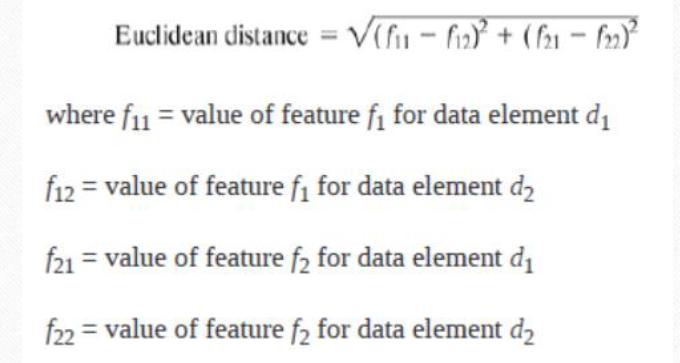

### Algorithm Steps

##### For a given test instance x: 

1. Calculate the distance between x and all points in the training set.
2. Sort the training points by distance from x.
3. Select the k nearest neighbors.
4. For classification, perform a majority vote among the k neighbors. For regression, average the k neighbors' values.

### Choosing the Right k

Selecting an appropriate value for k is crucial:

**Small k:** Can be noisy and lead to overfitting.

**Large k:** May smooth out the predictions too much and underfit the data.

A common approach is to use cross-validation to determine the optimal k value.

### Summary

k-Nearest Neighbors is a straightforward and versatile algorithm useful for both classification and regression. Its ease of implementation and lack of training phase make it an attractive choice for many problems, though its performance can be impacted by the size and dimensionality of the dataset. When using k-NN, careful consideration must be given to the choice of k and the distance metric to ensure optimal results.

### Model-1 diabetes.csv

In [40]:
import pandas as pd
data = pd.read_csv("diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [41]:
data.shape

(768, 9)

In [42]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [44]:
#Segregating predictor variables
x = data.iloc[:, 0:8]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [45]:
#Segregating the target/class variable
y = data['Outcome']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [46]:
#split into training and test datasets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state=1)

In [47]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [48]:
#kNN Classifier with k=27 means 27 closest neighbours are considered.
from sklearn.neighbors import KNeighborsClassifier
nn = KNeighborsClassifier(n_neighbors=15)

In [49]:
#Train the classifier with the training data
model = nn.fit(x_train, y_train)

In [50]:
prediction = model.predict(x_test)

In [51]:
prediction

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0])

In [52]:
diff=pd.DataFrame({"Actual":y_test,"Prediction":prediction})
diff

,Actual,Prediction
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [53]:
#To Store the data of above dataframe to a csv file 
diff.to_csv('diabetes_data.csv')   #To understand how confusion matrix come using Excel

In [54]:
#To Store the data of above dataframe to a csv file 
diff.to_excel('diabetes_data.xlsx')   #To understand how confusion matrix come using Excel

In [55]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
285,7,136,74,26,135,26.0,0.647,51
101,1,151,60,0,0,26.1,0.179,22
581,6,109,60,27,0,25.0,0.206,27
352,3,61,82,28,0,34.4,0.243,46
726,1,116,78,29,180,36.1,0.496,25
...,...,...,...,...,...,...,...,...
563,6,99,60,19,54,26.9,0.497,32
318,3,115,66,39,140,38.1,0.150,28
154,8,188,78,0,0,47.9,0.137,43
684,5,136,82,0,0,0.0,0.640,69


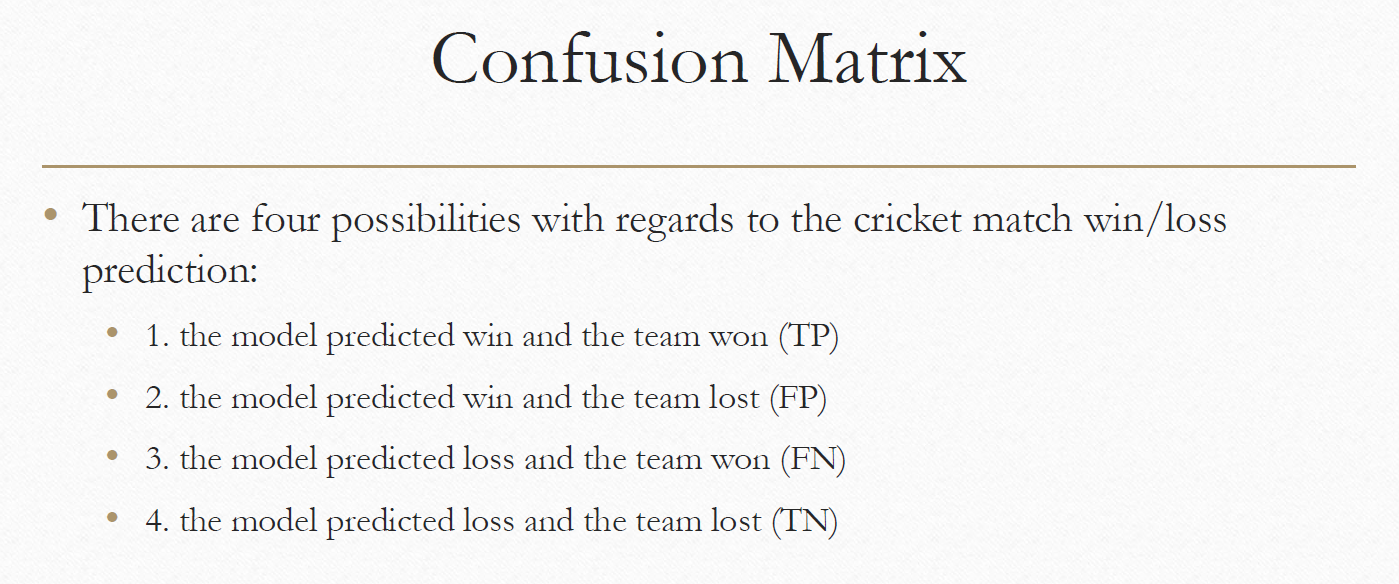

In [56]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction)
cm

array([[89, 10],
       [23, 32]])

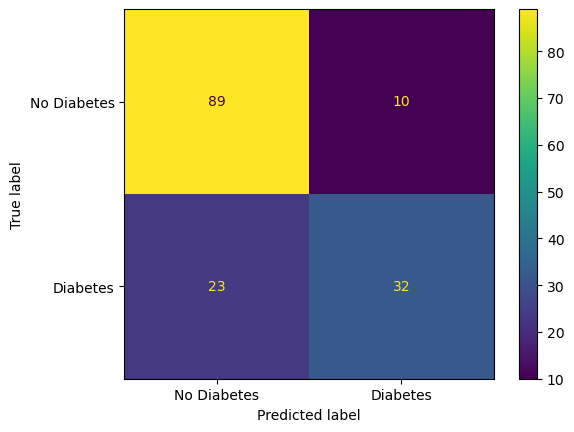

In [57]:
# visualize confusion matrix with sklearn metrics
# define matrix and create labels
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, 
                                            display_labels = ["No Diabetes", "Diabetes"])

# display matrix
cm_display.plot()
plt.show()

In [58]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print(TN, FP,FN,TP)

89 10 23 32


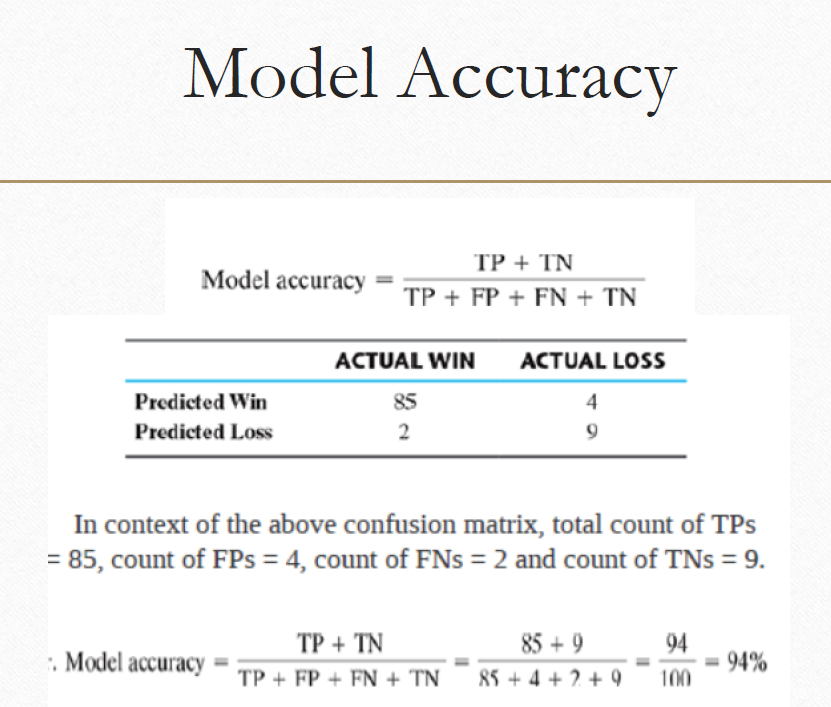

### Model Accuracy/Accuracy Score

In [59]:
Model_Accuracy=(TP+TN)/(TP+TN+FN+FP)
print("Accuracy Score:",Model_Accuracy)

Accuracy Score: 0.7857142857142857


In [60]:
from sklearn.metrics import accuracy_score
Accuracy=accuracy_score(y_test,prediction)
Accuracy

0.7857142857142857

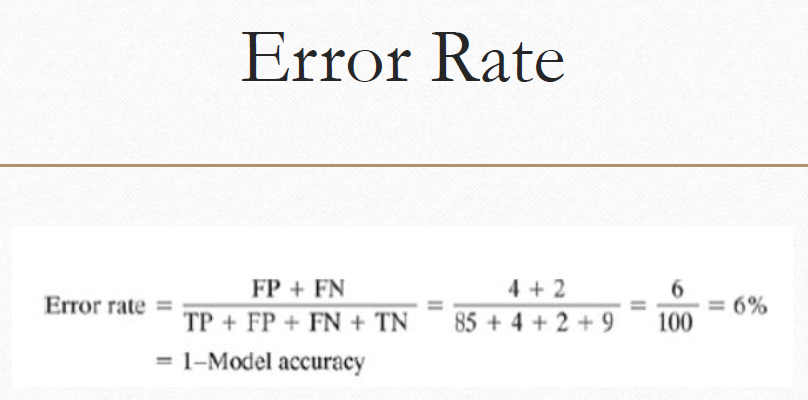

### Error Rate

In [61]:
Error_Rate=1-Model_Accuracy
print("Error Rate:", Error_Rate)

Error Rate: 0.2142857142857143


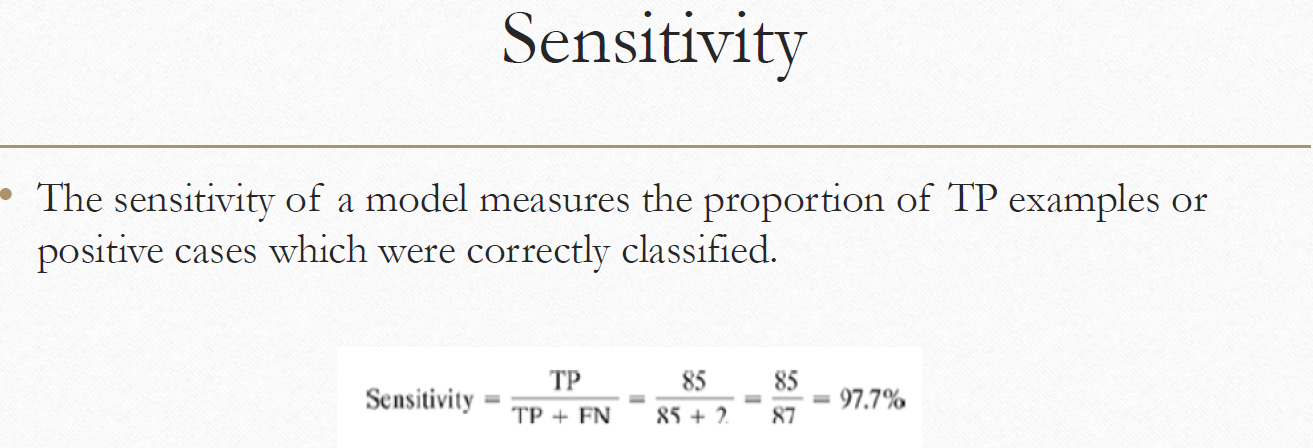

### Sensitivity

In [62]:
Sensitivity= TP / (TP + FN)
print("Sensitivity:",Sensitivity)

Sensitivity: 0.5818181818181818


In [63]:
from sklearn import metrics
print("Sensitivity:",metrics.recall_score(y_test,prediction))

Sensitivity: 0.5818181818181818


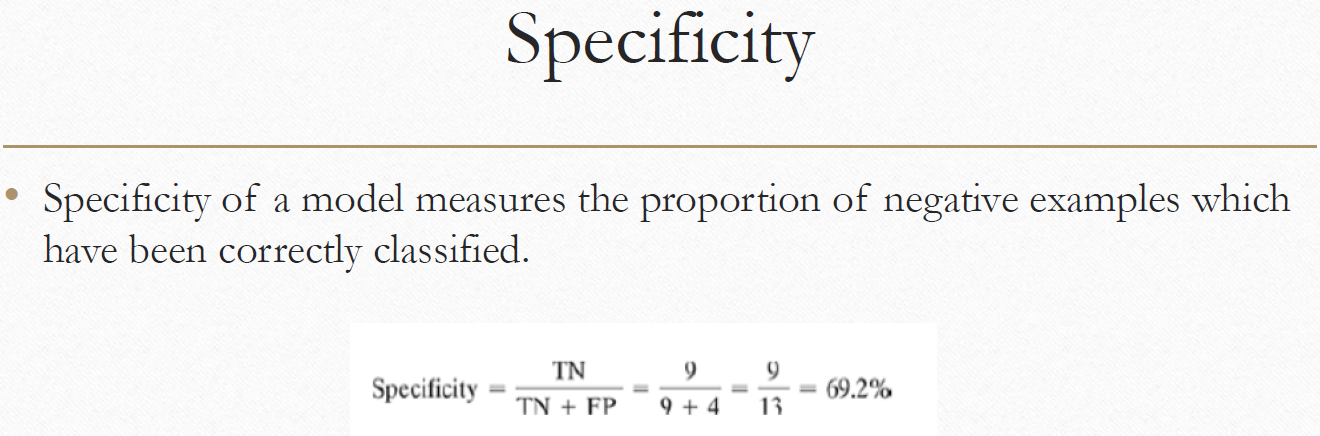

### Specificity

In [64]:
Specificity= TN / (TN + FP)
print("Specificity:",Specificity)

Specificity: 0.898989898989899


In [65]:
from sklearn import metrics
print("Specificity:",metrics.recall_score(y_test,prediction,pos_label=0))

Specificity: 0.898989898989899


### Precision Score

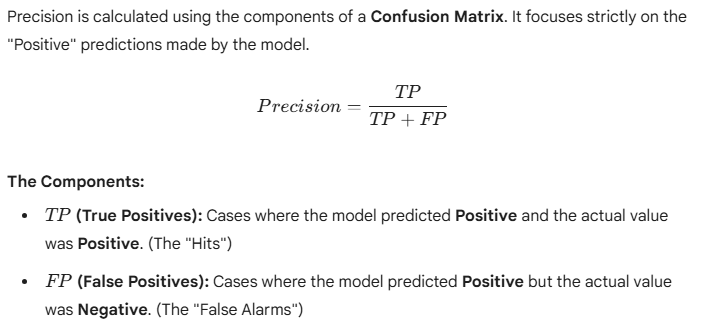

In [66]:
from sklearn import metrics
print("Precision Score:",metrics.precision_score(y_test,prediction))

Precision Score: 0.7619047619047619


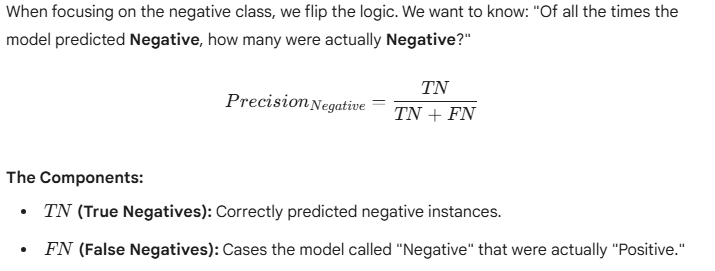

In [67]:
from sklearn import metrics
print("Precision Score:",metrics.precision_score(y_test,prediction,pos_label=0))

Precision Score: 0.7946428571428571


### To find the best value of k for highest accuracy_score.

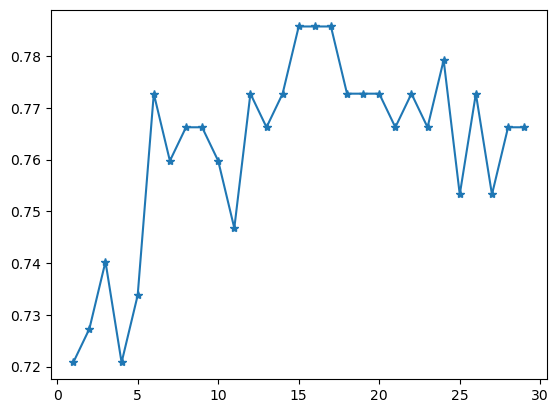

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663]


In [71]:
k=[]
for i in range (1,30):
    nn = KNeighborsClassifier(n_neighbors=i)
    model = nn.fit(x_train, y_train)
    prediction = model.predict(x_test)
    from sklearn.metrics import accuracy_score
    k.append(accuracy_score(y_test,prediction))
    
import matplotlib.pyplot as plt
plt.plot(range(1,30),k,marker="*")
plt.show()
print(k)

In [81]:
from sklearn.metrics import accuracy_score
k={}
for i in range (1,30):
    nn = KNeighborsClassifier(n_neighbors=i)
    model = nn.fit(x_train, y_train)
    prediction = model.predict(x_test)
    k[i]=accuracy_score(y_test,prediction)
print(k)

keys_list = list(k.keys())
values_list = list(k.values())
max_val = max(values_list)
max_index = values_list.index(max_val)
best_k = keys_list[max_index]
print(f"The first k with the max value is: {best_k}")


{1: 0.7207792207792207, 2: 0.7272727272727273, 3: 0.7402597402597403, 4: 0.7207792207792207, 5: 0.7337662337662337, 6: 0.7727272727272727, 7: 0.7597402597402597, 8: 0.7662337662337663, 9: 0.7662337662337663, 10: 0.7597402597402597, 11: 0.7467532467532467, 12: 0.7727272727272727, 13: 0.7662337662337663, 14: 0.7727272727272727, 15: 0.7857142857142857, 16: 0.7857142857142857, 17: 0.7857142857142857, 18: 0.7727272727272727, 19: 0.7727272727272727, 20: 0.7727272727272727, 21: 0.7662337662337663, 22: 0.7727272727272727, 23: 0.7662337662337663, 24: 0.7792207792207793, 25: 0.7532467532467533, 26: 0.7727272727272727, 27: 0.7532467532467533, 28: 0.7662337662337663, 29: 0.7662337662337663}
The first k with the max value is: 15


### Model-2 tshirt.csv

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [83]:
df=pd.read_csv('tshirt.csv')
df

,Height,Weight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [84]:
#Segregating predictor variables
x = df.iloc[:, 0:2]
y = df.iloc[:,2]

In [85]:
#Alternate Method to take x & y (Segregating predictor variables)
x=df[['Height','Weight']]
y=df['Size']

In [86]:
x.shape

(18, 2)

In [87]:
y.shape

(18,)

In [89]:
#kNN Classifier with k=9 means 9 closest neighbours are considered
nn = KNeighborsClassifier(n_neighbors=9)

In [90]:
#Train the classifier with the training data
model = nn.fit(x, y)

In [91]:
prediction = model.predict(x)

In [92]:
prediction

array(['M', 'M', 'M', 'M', 'M', 'M', 'L', 'M', 'L', 'L', 'L', 'L', 'L',
       'L', 'L', 'L', 'L', 'L'], dtype=object)

In [93]:
diff=pd.DataFrame({'Actual':y,"Predicted":prediction})
diff

,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [94]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, prediction)
cm

array([[10,  1],
       [ 1,  6]])

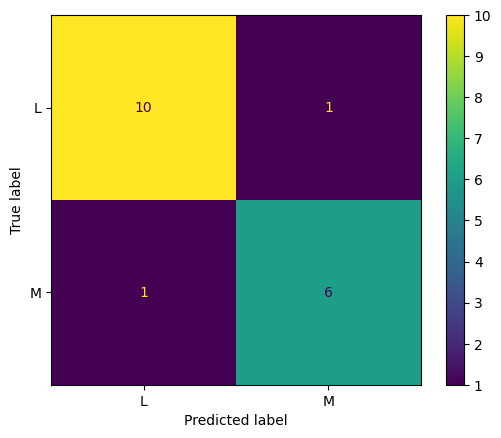

In [95]:
# visualize confusion matrix with sklearn metrics
# define matrix and create labels
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, 
                                            display_labels = ["L", "M"])

# display matrix
cm_display.plot()
plt.show()

In [96]:
TN=cm[0][0]
TP=cm[1][1]
FN=cm[1][0]
FP=cm[0][1]

print(TN,TP,FN,FP)

10 6 1 1


In [97]:
Model_Accuracy=(TP+TN)/(TP+TN+FN+FP)
print("Accuracy:",Model_Accuracy)

Accuracy: 0.8888888888888888


In [98]:
from sklearn.metrics import accuracy_score
print("Accuracy Score: ",accuracy_score(y,prediction))

Accuracy Score:  0.8888888888888888


In [99]:
Error_Rate=1-Model_Accuracy
print("Error Rate:", Error_Rate)

Error Rate: 0.11111111111111116


In [100]:
Sensitivity= TP / (TP + FN)
print("Sensitivity:",Sensitivity)

Sensitivity: 0.8571428571428571


In [105]:
from sklearn.metrics import recall_score
print(recall_score(y,prediction,pos_label='M'))

0.8571428571428571


In [101]:
Specificity= TN / (TN + FP)
print("Specificity:",Specificity)

Specificity: 0.9090909090909091


In [106]:
from sklearn.metrics import precision_score
print(recall_score(y,prediction,pos_label='L'))

0.9090909090909091


In [102]:
from sklearn.metrics import precision_score
print(precision_score(y,prediction,pos_label='L'))

0.9090909090909091


In [103]:
from sklearn.metrics import precision_score
print(precision_score(y,prediction,pos_label='M'))

0.8571428571428571


### To find the best value of k for highest accuracy_score.

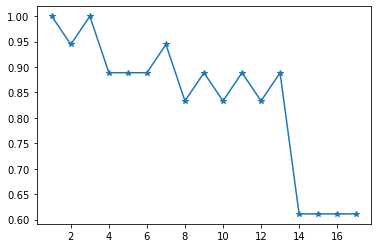

[1.0, 0.9444444444444444, 1.0, 0.8888888888888888, 0.8888888888888888, 0.8888888888888888, 0.9444444444444444, 0.8333333333333334, 0.8888888888888888, 0.8333333333333334, 0.8888888888888888, 0.8333333333333334, 0.8888888888888888, 0.6111111111111112, 0.6111111111111112, 0.6111111111111112, 0.6111111111111112]


In [57]:
k=[]
for i in range (1,18):
    nn = KNeighborsClassifier(n_neighbors=i)
    model = nn.fit(x,y)
    prediction = model.predict(x)
    from sklearn.metrics import accuracy_score
    k.append(accuracy_score(y,prediction))
    
import matplotlib.pyplot as plt
plt.plot(range(1,18),k,marker="*")
plt.show()
print(k)

### AptitudeCommunication.csv 

In [70]:
import pandas as pd
df=pd.read_csv('AptitudeCommunication.csv')
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [71]:
x=df[['Aptitude','Communication']]
y=df['Class']

In [72]:
x.shape

(14, 2)

In [73]:
y.shape

(14,)

In [74]:
from sklearn.neighbors import KNeighborsClassifier

nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
y_pred=model.predict(x)
y_pred

array(['Speaker', 'Speaker', 'Leader', 'Intel', 'Leader', 'Speaker',
       'Intel', 'Speaker', 'Intel', 'Leader', 'Intel', 'Leader', 'Intel',
       'Leader'], dtype=object)

In [75]:
diff=pd.DataFrame({"Actual":y,"Predicted":y_pred})
diff

,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [76]:
#Prediction for specific values of Aptitude & Communication
prediction=model.predict([[5,4.5]])
prediction

array(['Intel'], dtype=object)

In [77]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred)
cm

array([[5, 0, 0],
       [0, 5, 0],
       [0, 0, 4]], dtype=int64)

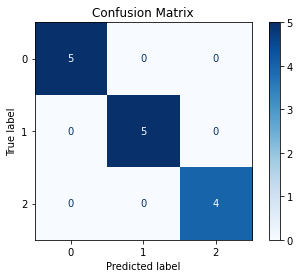

In [79]:
# Display the confusion matrix
cm = confusion_matrix(y, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [80]:
from sklearn.metrics import accuracy_score
print("accuracy_score:", accuracy_score(y,y_pred))

accuracy_score: 1.0


### To find the best value of k for highest accuracy_score

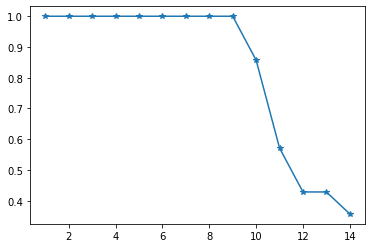

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8571428571428571, 0.5714285714285714, 0.42857142857142855, 0.42857142857142855, 0.35714285714285715]


In [67]:
k=[]
for i in range (1,15):
    nn = KNeighborsClassifier(n_neighbors=i)
    model = nn.fit(x,y)
    prediction = model.predict(x)
    from sklearn.metrics import accuracy_score
    k.append(accuracy_score(y,prediction))
    
import matplotlib.pyplot as plt
plt.plot(range(1,15),k,marker="*")
plt.show()
print(k)